# Law article chunking 

In [205]:
# import
from langchain_text_splitters import  RecursiveCharacterTextSplitter
import json

 1 - Here we will chunk the law articles into smaller pieces, and then we will use the chunks to create the embeddings. We will use the RecursiveCharacterTextSplitter from langchain_text_splitters to split the text into chunks of a maximum of 500 characters, with an overlap of 9 characters between chunks. 

In [206]:
'''
with open(r"../data/preprossed/cleaned/cleaned_source_6.txt",encoding="utf-8") as f:
    text = f.read()

with open(r"../data/preprossed/cleaned/metadata_source_6.json",encoding="utf-8") as f:
    metadata = json.load(f)

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=9,separators=["Article"])
chunks = text_splitter.create_documents([text])

value = metadata[0].pop("page_number",None) 
index = 0

for i , chunk in enumerate(chunks,start=1):
    chunk.metadata = metadata[0].copy()
    chunk.metadata["chunk_index"] = i
    


with open(r"../data/preprossed/cleaned/chunks_source_6.json", "w", encoding="utf-8") as f:
    json.dump([{"page_content": chunk.page_content , "metadata" : chunk.metadata, } for chunk in chunks], f, ensure_ascii=False, indent=4)
''' 

'\nwith open(r"../data/preprossed/cleaned/cleaned_source_6.txt",encoding="utf-8") as f:\n    text = f.read()\n\nwith open(r"../data/preprossed/cleaned/metadata_source_6.json",encoding="utf-8") as f:\n    metadata = json.load(f)\n\ntext_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=9,separators=["Article"])\nchunks = text_splitter.create_documents([text])\n\nvalue = metadata[0].pop("page_number",None) \nindex = 0\n\nfor i , chunk in enumerate(chunks,start=1):\n    chunk.metadata = metadata[0].copy()\n    chunk.metadata["chunk_index"] = i\n\n\n\nwith open(r"../data/preprossed/cleaned/chunks_source_6.json", "w", encoding="utf-8") as f:\n    json.dump([{"page_content": chunk.page_content , "metadata" : chunk.metadata, } for chunk in chunks], f, ensure_ascii=False, indent=4)\n'

In [207]:
'''
with open(r"../data/preprossed/cleaned/cleaned_source_5.txt",encoding="utf-8") as f:
    text = f.read()

with open(r"../data/preprossed/cleaned/metadata_source_5.json",encoding="utf-8") as f:
    metadata = json.load(f)

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=9,separators=["Article"])
chunks = text_splitter.create_documents([text])

value = metadata[0].pop("page_number",None) 
index = 0

for i , chunk in enumerate(chunks,start=1):
    chunk.metadata = metadata[0].copy()
    chunk.metadata["chunk_index"] = i
    


with open(r"../data/preprossed/cleaned/chunks_source_5.json", "w", encoding="utf-8") as f:
    json.dump([{"page_content": chunk.page_content , "metadata" : chunk.metadata, } for chunk in chunks], f, ensure_ascii=False, indent=4)
'''

'\nwith open(r"../data/preprossed/cleaned/cleaned_source_5.txt",encoding="utf-8") as f:\n    text = f.read()\n\nwith open(r"../data/preprossed/cleaned/metadata_source_5.json",encoding="utf-8") as f:\n    metadata = json.load(f)\n\ntext_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=9,separators=["Article"])\nchunks = text_splitter.create_documents([text])\n\nvalue = metadata[0].pop("page_number",None) \nindex = 0\n\nfor i , chunk in enumerate(chunks,start=1):\n    chunk.metadata = metadata[0].copy()\n    chunk.metadata["chunk_index"] = i\n\n\n\nwith open(r"../data/preprossed/cleaned/chunks_source_5.json", "w", encoding="utf-8") as f:\n    json.dump([{"page_content": chunk.page_content , "metadata" : chunk.metadata, } for chunk in chunks], f, ensure_ascii=False, indent=4)\n'

In [208]:
'''
with open(r"../data/preprossed/cleaned/chunks_source_6.json", encoding="utf-8") as f:
    chunk = json.load(f)
print(chunk[0])
'''

'\nwith open(r"../data/preprossed/cleaned/chunks_source_6.json", encoding="utf-8") as f:\n    chunk = json.load(f)\nprint(chunk[0])\n'

# Guide articles chunking 

In [209]:
import re

with open(r"../data/preprossed/cleaned/cleaned_source_4.txt",encoding="utf-8") as f:
    text = f.read()
    


Semantic Chunking 

In [210]:

# Splitting the essay on '.', '?', and '!'
single_sentences_list = re.split(r'(?<=[.?!])\s+', text)
#single_sentences_list = re.split(r'(?<=[?])\s+', text)
print (f"{len(single_sentences_list)} senteneces were found")
'''
chunks = text_splitter.create_documents([text])
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}: \n {chunk.page_content}")
    print('==================================================================================')
'''

165 senteneces were found


'\nchunks = text_splitter.create_documents([text])\nfor i, chunk in enumerate(chunks):\n    print(f"Chunk {i+1}: \n {chunk.page_content}")\n    print(\'==================================================================================\')\n'

In [211]:
sentences = [{'sentence': x, 'index' : i} for i, x in enumerate(single_sentences_list)]
sentences[:3]

[{'sentence': "La prévention vaccinale  \nL'essentiel :\n\nEn 1983, un vaccin vivant atténué est développé.",
  'index': 0},
 {'sentence': 'Plusieurs études ont montré sa tolérance et son efficacité, Son immunogénéicité est tellement haute que 95% des enfants de plus de 2 ans développent des anticorps anti-hépatite virale À à 1 mois après la primo-injection.',
  'index': 1},
 {'sentence': 'Les pays à revenu intermédiaire retireraient le plus grand avantage des programmes de vaccination à grande échelle contre le VHA.',
  'index': 2}]

In [212]:
def combine_sentences(sentences, buffer_size=1):
    # Go through each sentence dict
    for i in range(len(sentences)):

        # Create a string that will hold the sentences which are joined
        combined_sentence = ''

        # Add sentences before the current one, based on the buffer size.
        for j in range(i - buffer_size, i):
            # Check if the index j is not negative (to avoid index out of range like on the first one)
            if j >= 0:
                # Add the sentence at index j to the combined_sentence string
                combined_sentence += sentences[j]['sentence'] + ' '

        # Add the current sentence
        combined_sentence += sentences[i]['sentence']

        # Add sentences after the current one, based on the buffer size
        for j in range(i + 1, i + 1 + buffer_size):
            # Check if the index j is within the range of the sentences list
            if j < len(sentences):
                # Add the sentence at index j to the combined_sentence string
                combined_sentence += ' ' + sentences[j]['sentence']

        # Then add the whole thing to your dict
        # Store the combined sentence in the current sentence dict
        sentences[i]['combined_sentence'] = combined_sentence

    return sentences

sentences = combine_sentences(sentences)

In [213]:
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv

load_dotenv()
# Runs locally — no API call, no task compatibility issue
embeddings_hugging_face = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True}
)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3118.10it/s]
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [214]:

# Your loop works as before
embeddings = []
for sentence in sentences:
    embeddings.append(
        embeddings_hugging_face.embed_query(sentence['combined_sentence'])
    )

for i, sentence in enumerate(sentences):
    sentence['combined_sentence_embedding'] = embeddings[i]

In [215]:

for i, sentence in enumerate(sentences):
    sentence['combined_sentence_embedding'] = embeddings[i]


In [216]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_cosine_distances(sentences):
    distances = []
    for i in range(len(sentences) - 1):
        embedding_current = sentences[i]['combined_sentence_embedding']
        embedding_next = sentences[i + 1]['combined_sentence_embedding']
        
        # Calculate cosine similarity
        similarity = cosine_similarity([embedding_current], [embedding_next])[0][0]
        
        # Convert to cosine distance
        distance = 1 - similarity

        # Append cosine distance to the list
        distances.append(distance)

        # Store distance in the dictionary
        sentences[i]['distance_to_next'] = distance

    # Optionally handle the last sentence
        sentences[-1]['distance_to_next'] = None  # or a default value

    return distances, sentences

In [217]:
distances, sentences = calculate_cosine_distances(sentences)

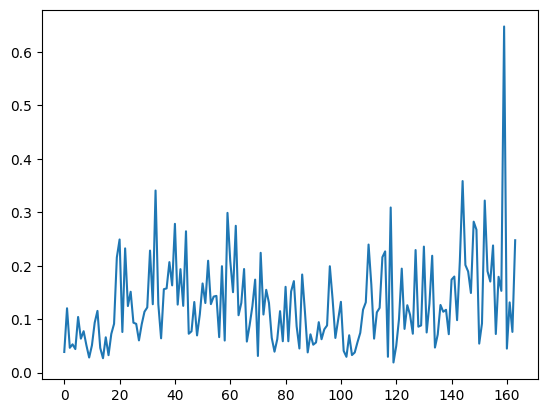

In [218]:
import matplotlib.pyplot as plt

plt.plot(distances);

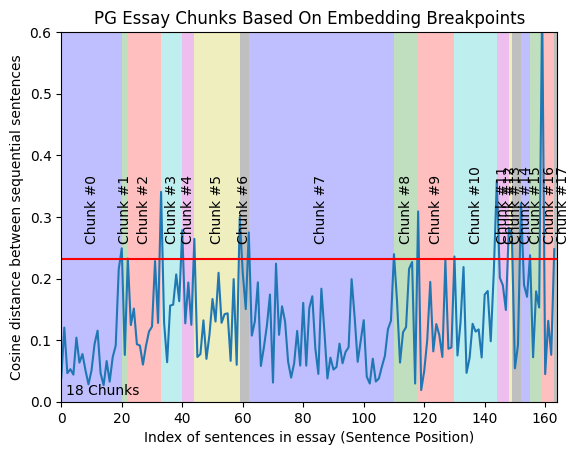

In [ ]:
import numpy as np

plt.plot(distances);

y_upper_bound = .6
plt.ylim(0, y_upper_bound)
plt.xlim(0, len(distances))

# We need to get the distance threshold that we'll consider an outlier
# We'll use numpy .percentile() for this
# breakpoint_percentile_threshold = [80 , 94 , 75 , 90] for each source
breakpoint_percentile_threshold = 90
breakpoint_distance_threshold = np.percentile(distances, breakpoint_percentile_threshold) # If you want more chunks, lower the percentile cutoff
plt.axhline(y=breakpoint_distance_threshold, color='r', linestyle='-');

# Then we'll see how many distances are actually above this one
num_distances_above_theshold = len([x for x in distances if x > breakpoint_distance_threshold]) # The amount of distances above your threshold
plt.text(x=(len(distances)*.01), y=y_upper_bound/50, s=f"{num_distances_above_theshold + 1} Chunks");

# Then we'll get the index of the distances that are above the threshold. This will tell us where we should split our text
indices_above_thresh = [i for i, x in enumerate(distances) if x > breakpoint_distance_threshold] # The indices of those breakpoints on your list

# Start of the shading and text
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']
for i, breakpoint_index in enumerate(indices_above_thresh):
    start_index = 0 if i == 0 else indices_above_thresh[i - 1]
    end_index = breakpoint_index if i < len(indices_above_thresh) - 1 else len(distances)

    plt.axvspan(start_index, end_index, facecolor=colors[i % len(colors)], alpha=0.25)
    plt.text(x=np.average([start_index, end_index]),
             y=breakpoint_distance_threshold + (y_upper_bound)/ 20,
             s=f"Chunk #{i}", horizontalalignment='center',
             rotation='vertical')

# # Additional step to shade from the last breakpoint to the end of the dataset
if indices_above_thresh:
    last_breakpoint = indices_above_thresh[-1]
    if last_breakpoint < len(distances):
        plt.axvspan(last_breakpoint, len(distances), facecolor=colors[len(indices_above_thresh) % len(colors)], alpha=0.25)
        plt.text(x=np.average([last_breakpoint, len(distances)]),
                 y=breakpoint_distance_threshold + (y_upper_bound)/ 20,
                 s=f"Chunk #{i+1}",
                 rotation='vertical')

plt.title("PG Essay Chunks Based On Embedding Breakpoints")
plt.xlabel("Index of sentences in essay (Sentence Position)")
plt.ylabel("Cosine distance between sequential sentences")
plt.show()

In [220]:
# Initialize the start index
start_index = 0

# Create a list to hold the grouped sentences
chunks = []

# Iterate through the breakpoints to slice the sentences
for index in indices_above_thresh:
    # The end index is the current breakpoint
    end_index = index

    # Slice the sentence_dicts from the current start index to the end index
    group = sentences[start_index:end_index + 1]
    combined_text = ' '.join([d['sentence'] for d in group])
    chunks.append(combined_text)
    
    # Update the start index for the next group
    start_index = index + 1

# The last group, if any sentences remain
if start_index < len(sentences):
    combined_text = ' '.join([d['sentence'] for d in sentences[start_index:]])
    chunks.append(combined_text)

# grouped_sentences now contains the chunked sentences

 Save the chunks in a json file, with the following format : [{"page_content": chunk.page_content , "metadata" : chunk.metadata, }]

In [221]:
with open(r"../data/preprossed/cleaned/metadata_source_4.json",encoding="utf-8") as f:
    metadata = json.load(f)
value = metadata[0].pop("page_number",None) 


chunks_with_metadata = []
for i , chunk in enumerate(chunks,start=1):
    chunk_doc = {
        "page_content": chunk,
        "metadata": metadata[0].copy()
    }
    chunk_doc["metadata"]["chunk_index"] = i
    chunks_with_metadata.append(chunk_doc)
    
    
    

with open(r"../data/preprossed/cleaned/chunks_source_4.json", "w", encoding="utf-8") as f:
    json.dump(chunks_with_metadata, f, ensure_ascii=False, indent=4)
    